In [147]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neural_network import MLPClassifier # untuk perbandingan

from model.network import NeuralNetwork
from model.layers import DenseLayer
from model.activation import ActivationLayer

In [148]:
# load dataset
data = pd.read_csv('data/datasetml_2026.csv')

## 1. Exploratory Data Analysis (EDA)

### 1.1 Informasi Umum Data

In [149]:
data.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [150]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      10000 non-null  float64
 1   backlogs                  10000 non-null  int64  
 2   college_tier              10000 non-null  object 
 3   country                   10000 non-null  object 
 4   university_ranking_band   10000 non-null  object 
 5   internship_count          10000 non-null  int64  
 6   aptitude_score            10000 non-null  float64
 7   communication_score       10000 non-null  float64
 8   specialization            10000 non-null  object 
 9   industry                  10000 non-null  object 
 10  internship_quality_score  10000 non-null  float64
 11  placement_status          10000 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 937.6+ KB


In [151]:
data.describe()

,cgpa,backlogs,internship_count,aptitude_score,communication_score,internship_quality_score
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,6.998290,1.248100,1.49930,69.877531,65.158600,5.021436
std,0.802606,1.149904,1.20289,14.700532,14.740446,1.505975
min,4.000000,0.000000,0.00000,30.000000,30.000000,1.000000
25%,6.461928,0.000000,1.00000,59.880399,55.112244,4.012656
50%,6.997924,1.000000,1.00000,70.097368,65.006484,5.017335
75%,7.536865,2.000000,2.00000,80.213934,75.277248,6.031400
max,10.000000,6.000000,5.00000,100.000000,100.000000,10.000000


In [152]:
# Cek missing values
missing = data.isnull().sum()
missing_pct = (missing / len(data) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct}).query('`Missing Count` > 0')

,Missing Count,Missing (%)


In [153]:
# Distribusi kelas target
print(data['placement_status'].value_counts())
print(data['placement_status'].value_counts(normalize=True).round(3))

placement_status
Placed        6153
Not Placed    3847
Name: count, dtype: int64
placement_status
Placed        0.615
Not Placed    0.385
Name: proportion, dtype: float64


### 1.2 Visualisasi Data

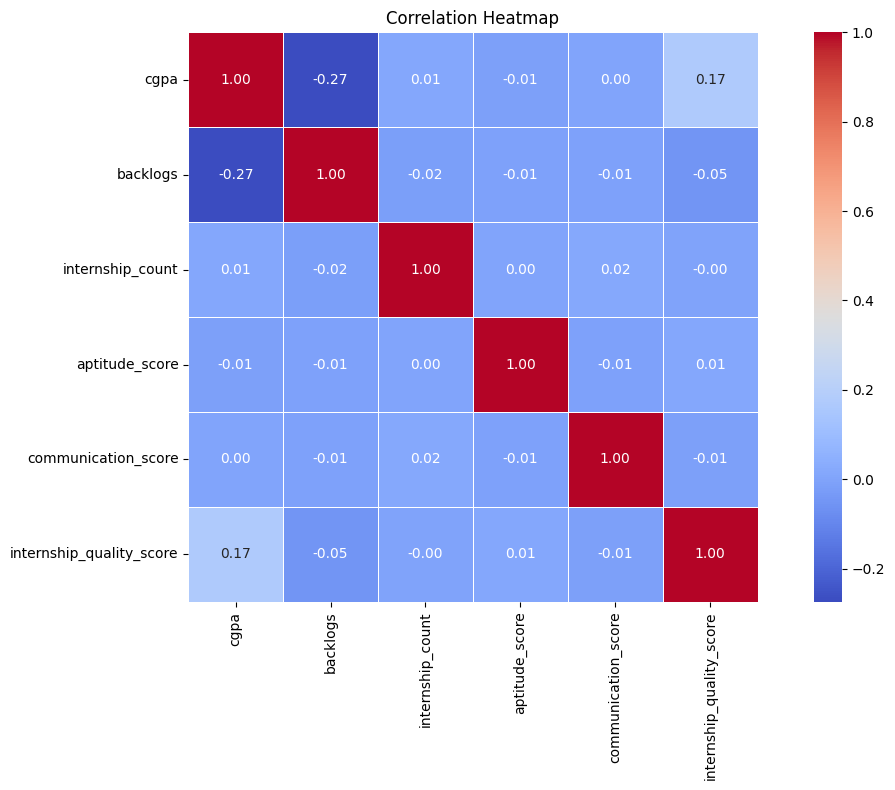

In [154]:
# Snippet: heatmap korelasi fitur numerik
# -------------------------------------------------------
num_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()


plt.figure(figsize=(12, 8))
corr_matrix = data[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

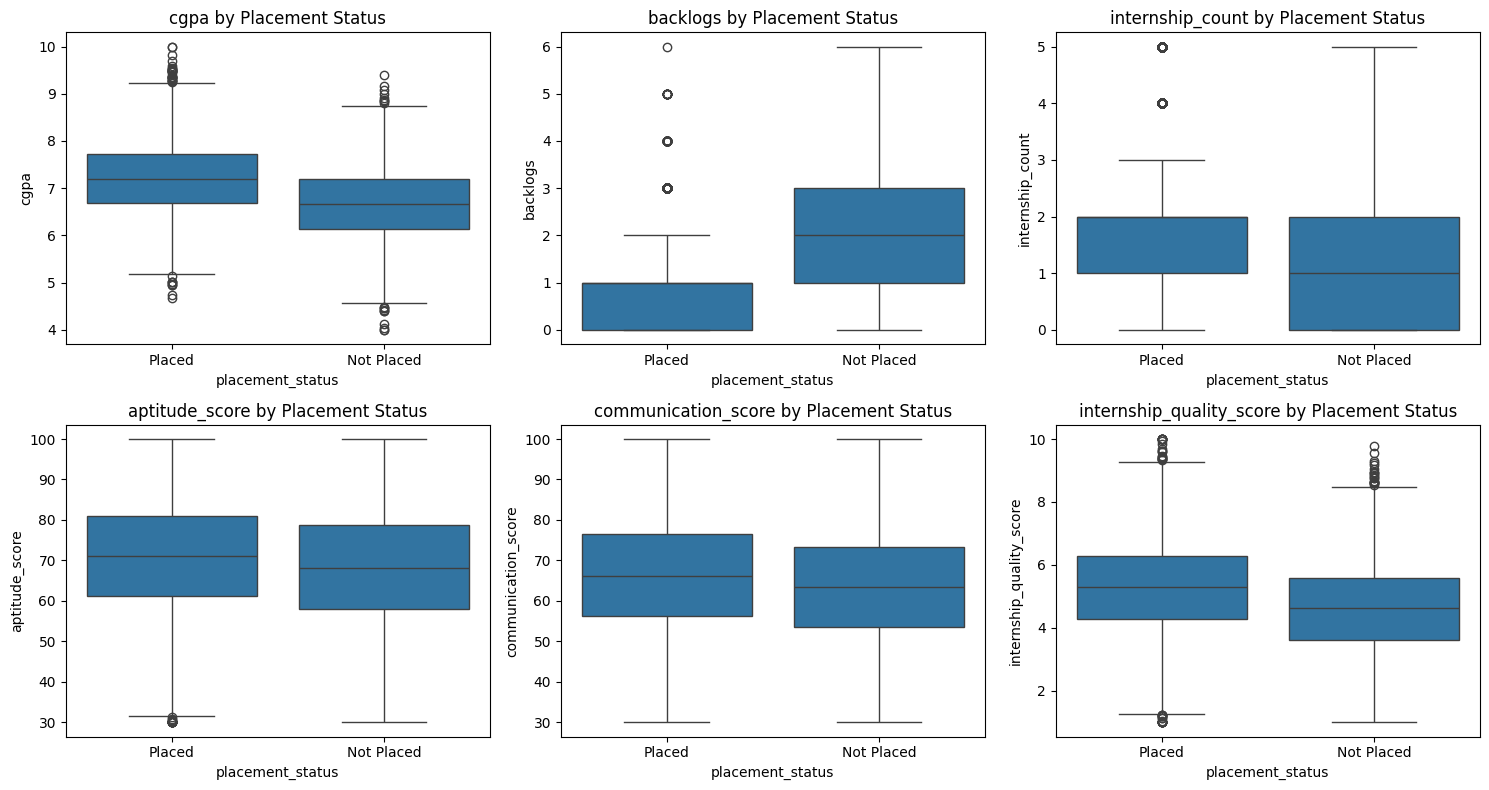

In [155]:
# Snippet: boxplot untuk deteksi outlier per kelas target
# -------------------------------------------------------
num_features = [col for col in num_cols if col != 'placement_status']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_features):
    sns.boxplot(data=data, x='placement_status', y=col, ax=ax)
    ax.set_title(f'{col} by Placement Status')

plt.tight_layout()
plt.show()

### 2. Data Cleaning dan Preprocessing

In [156]:
# Salin data
data_copy = data.copy()

In [157]:
TARGET_COL = 'placement_status'

CAT_COLS = ['college_tier', 'country', 'university_ranking_band', 'specialization', 'industry', 'placement_status']
NUM_COLS = [c for c in data_copy.columns if c not in CAT_COLS + [TARGET_COL]]

print("Categorical Columns:", CAT_COLS)
print("Numerical Columns:", NUM_COLS)

Categorical Columns: ['college_tier', 'country', 'university_ranking_band', 'specialization', 'industry', 'placement_status']
Numerical Columns: ['cgpa', 'backlogs', 'internship_count', 'aptitude_score', 'communication_score', 'internship_quality_score']


In [158]:
# Handling missing values
# Snippet: SimpleImputer
# -------------------------------------------------------
from sklearn.impute import SimpleImputer


num_imputer = SimpleImputer(strategy='median')  
data_copy[NUM_COLS] = num_imputer.fit_transform(data_copy[NUM_COLS])

cat_imputer = SimpleImputer(strategy='most_frequent')
data_copy[CAT_COLS] = cat_imputer.fit_transform(data_copy[CAT_COLS])


In [159]:
# Handling outlier
# Snippet: Deteksi outlier dengan IQR
# -------------------------------------------------------
def get_iqr_bounds(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

for col in NUM_COLS:
    lower, upper = get_iqr_bounds(data_copy[col])
    data_copy[col] = data_copy[col].clip(lower, upper)
    n = ((data_copy[col] < lower) | (data_copy[col] > upper)).sum()


    print(f"{col}: {n} outliers")

cgpa: 0 outliers
backlogs: 0 outliers
internship_count: 0 outliers
aptitude_score: 0 outliers
communication_score: 0 outliers
internship_quality_score: 0 outliers


In [160]:
from sklearn.preprocessing import StandardScaler

# Inisialisasi Scaler
scaler = StandardScaler()

data_copy[NUM_COLS] = scaler.fit_transform(data_copy[NUM_COLS])

In [161]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    drop='first',
    handle_unknown='ignore',
    sparse_output=False
)

# Fit hanya di data_copying
encoder.fit(data_copy[CAT_COLS])

# Transform keduanya
data_copy_encoded = encoder.transform(data_copy[CAT_COLS])

data_copy_encoded = pd.DataFrame(
    data_copy_encoded,
    columns=encoder.get_feature_names_out(CAT_COLS),
)


data_copy = pd.concat(
    [data_copy.drop(columns=CAT_COLS), data_copy_encoded],
    axis=1
)


In [162]:
data_copy.head()

,cgpa,backlogs,internship_count,aptitude_score,communication_score,internship_quality_score,college_tier_Tier 2,college_tier_Tier 3,country_Germany,country_India,...,specialization_Cloud,specialization_Core CS,specialization_Cybersecurity,specialization_Data Science,industry_Finance,industry_Healthcare,industry_Manufacturing,industry_Other,industry_Tech,placement_status_Placed
0,0.500827,-0.215264,0.507104,-1.109089,-0.066591,0.307502,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.136713,-1.093174,-0.411396,-0.625164,1.573128,-0.262938,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.652410,-1.093174,0.507104,-0.361147,0.294074,0.138631,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,1.531283,-1.093174,1.425604,0.243811,0.885109,0.087162,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
4,-0.232989,-0.215264,1.884855,1.132029,-1.389289,-0.753392,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [163]:
from sklearn.model_selection import train_test_split


feature_cols = [c for c in data_copy.columns if c not in [TARGET_COL]]

X = data_copy[feature_cols]
y = data_copy['placement_status_Placed']

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,        
    random_state=42,
    stratify=y          
)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape,   "| y_val:  ", y_val.shape)

X_train: (8000, 24) | y_train: (8000,)
X_val:   (2000, 24) | y_val:   (2000,)


In [164]:
X_train_np = X_train.to_numpy()
y_train_np = y_train.to_numpy().reshape(-1, 1)

X_val_np = X_val.to_numpy()
y_val_np = y_val.to_numpy().reshape(-1, 1)

### 3. Modeling and Validation

In [165]:
# Helper: evaluasi model dan simpan hasil
from sklearn.metrics import f1_score


results = {}

def evaluate_model(model, X_val, y_val, model_name="Model"):
    y_pred = model.predict(X_val)
    print(f"{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(classification_report(y_val, y_pred,
                                target_names=['Rejected (0)', 'Approved (1)']))
    macro_f1 = f1_score(y_val, y_pred, average='macro')
    print(f">>> Macro F1-Score: {macro_f1:.4f}\n")
    return macro_f1

In [166]:
#  init import class 

from model.functions import ActivationFunctions, LossFunctions
from model.initializers import Initializers

activation_fn = ActivationFunctions()
loss_fn = LossFunctions()
init_fn = Initializers()

relu = activation_fn.relu
relu_prime = activation_fn.relu_prime
sigmoid = activation_fn.sigmoid
sigmoid_prime = activation_fn.sigmoid_prime
linear = activation_fn.linear
linear_prime = activation_fn.linear_prime
softmax = activation_fn.softmax
softmax_prime = activation_fn.softmax_prime
hyperbolic_tangent = activation_fn.hyperbolic_tangent
hyperbolic_tangent_prime = activation_fn.hyperbolic_tangent_prime

mse = loss_fn.mse
mse_prime = loss_fn.mse_prime
bce = loss_fn.binary_cross_entropy
bce_prime = loss_fn.bce_prime
cce = loss_fn.categorical_cross_entropy
cce_prime = loss_fn.cce_prime

normal_init = init_fn.normal_init
uniform_init = init_fn.uniform_init
he_init = init_fn.he_init
uniform_init = init_fn.uniform_init
xavier_init = init_fn.xavier_init

Memulai 5-Fold Cross Validation...



Fold 1 Accuracy: 1.0000
Fold 2 Accuracy: 1.0000
Fold 3 Accuracy: 1.0000
Fold 4 Accuracy: 1.0000
Fold 5 Accuracy: 1.0000
------------------------------
Rata-rata Akurasi (5-Fold): 1.0000
Standar Deviasi: 0.0000


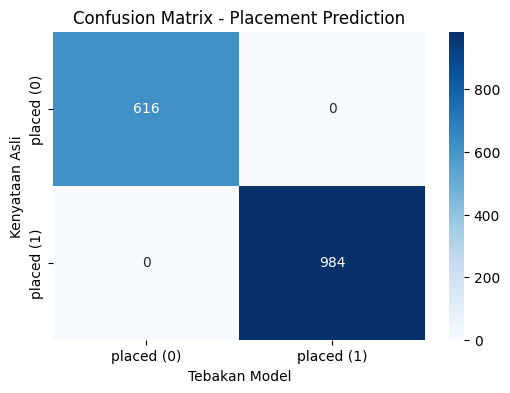

In [167]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import numpy as np

k = 5 # Jumlah fold
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

fold_accuracies = []

print(f"Memulai {k}-Fold Cross Validation...\n")


for i, (train_index, test_index) in enumerate(skf.split(X_train_np, y_train_np)):
    
    # Bagi data berdasarkan indeks dari sklearn
    X_train_fold, X_val_fold = X_train_np[train_index], X_train_np[test_index]
    y_train_fold, y_val_fold = y_train_np[train_index], y_train_np[test_index]
    
    model_fold = NeuralNetwork()
    model_fold.add(DenseLayer(24, 10, initializer_func=normal_init, mean=0, variance=0.1))  
    model_fold.add(ActivationLayer(hyperbolic_tangent, hyperbolic_tangent_prime))
    model_fold.add(DenseLayer(10, 1, initializer_func=normal_init, mean=0, variance=0.1))
    model_fold.add(ActivationLayer(sigmoid, sigmoid_prime))
    
    model_fold.use(mse, mse_prime)

    model_fold.train(X_train_fold, y_train_fold, epochs=500, learning_rate=0.1, verbose=False)
    
    y_pred_fold = model_fold.predict(X_val_fold)
    
    y_pred_flattened = np.array(y_pred_fold).flatten()
    
    # Ubah ke biner (0 atau 1)
    y_pred_binary = (y_pred_flattened >= 0.5).astype(int)
    
    # Hitung akurasi
    acc = accuracy_score(y_val_fold, y_pred_binary)
    fold_accuracies.append(acc)
    
    print(f"Fold {i+1} Accuracy: {acc:.4f}")


print("-" * 30)
print(f"Rata-rata Akurasi ({k}-Fold): {np.mean(fold_accuracies):.4f}")
print(f"Standar Deviasi: {np.std(fold_accuracies):.4f}")

cm = confusion_matrix(y_val_fold, y_pred_binary)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['placed (0)', 'placed (1)'], 
            yticklabels=['placed (0)', 'placed (1)'])
plt.xlabel('Tebakan Model')
plt.ylabel('Kenyataan Asli')
plt.title('Confusion Matrix - Placement Prediction')
plt.show()

## Pengujian

### Pengujian 1. Hyperparameter

### Pengujian 1.1. Pengaruh Width dan Depth

#### Width berbeda


Training model dengan Width: 4

Training model dengan Width: 16

Training model dengan Width: 64


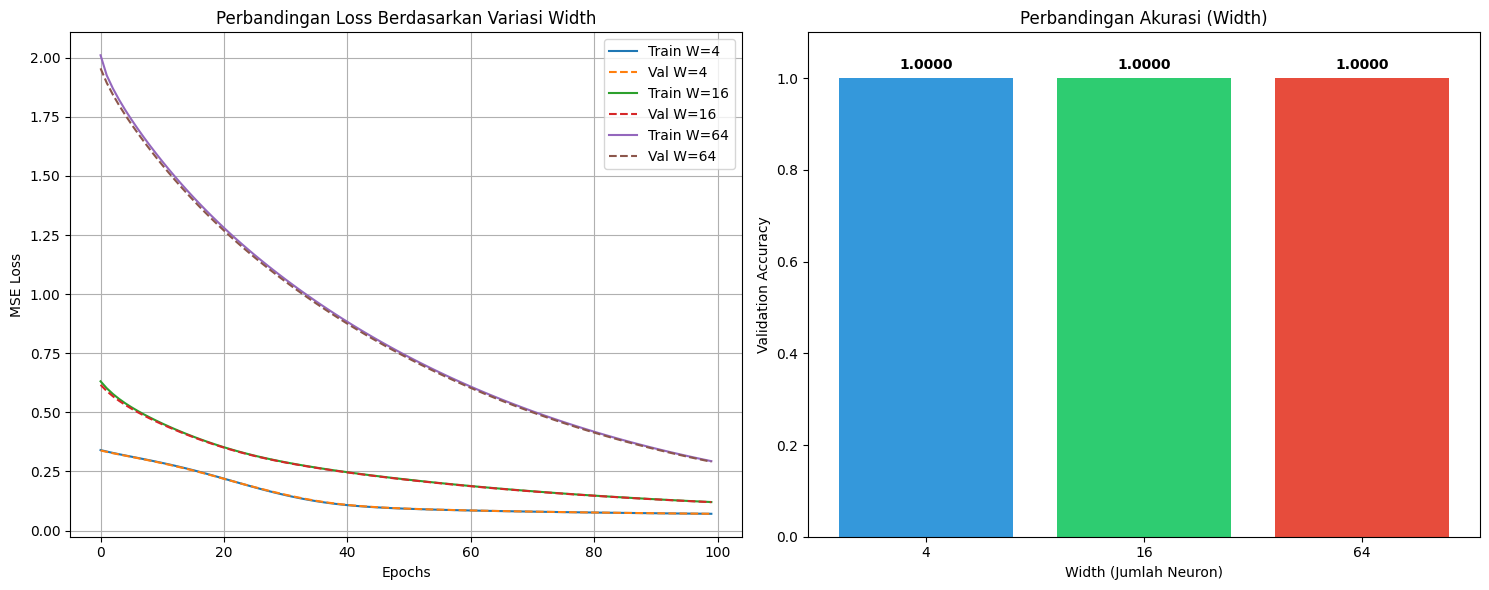

In [168]:
import matplotlib.pyplot as plt

widths = [4, 16, 64] # Kecil, Menengah, Besar
results = {}
val_accuracies = []

for w in widths:
    print(f"\nTraining model dengan Width: {w}")
    
    model = NeuralNetwork()
    
    model.add(DenseLayer(24, w, he_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
    model.add(ActivationLayer(relu, relu_prime))
    
    model.add(DenseLayer(w, w, xavier_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
    model.add(ActivationLayer(relu, relu_prime))
    
    model.add(DenseLayer(w, 1, xavier_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
    model.add(ActivationLayer(sigmoid, sigmoid_prime))

    model.use(mse, mse_prime)

    results[w] = model.train(
        X_train_np, y_train_np,
        X_val_np, y_val_np,
        epochs=100,
        batch_size=32,
        learning_rate=0.1,
        verbose=0
    )

    y_pred = model.predict(X_val_np)
    y_pred_binary = (np.array(y_pred).flatten() >= 0.5).astype(int)
    acc = accuracy_score(y_val_np, y_pred_binary)
    val_accuracies.append(acc)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

for w in widths:
    ax1.plot(results[w]['train_loss'], label=f'Train W={w}')
    ax1.plot(results[w]['val_loss'], '--', label=f'Val W={w}')
ax1.set_title('Perbandingan Loss Berdasarkan Variasi Width')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('MSE Loss')
ax1.legend()
ax1.grid(True)

bars = ax2.bar([str(w) for w in widths], val_accuracies, color=['#3498db', '#2ecc71', '#e74c3c'])
ax2.set_title('Perbandingan Akurasi (Width)')
ax2.set_xlabel('Width (Jumlah Neuron)')
ax2.set_ylabel('Validation Accuracy')
ax2.set_ylim(0, 1.1)
for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Depth Berbeda


Training model dengan Depth: 1 Hidden Layers

Training model dengan Depth: 2 Hidden Layers

Training model dengan Depth: 4 Hidden Layers


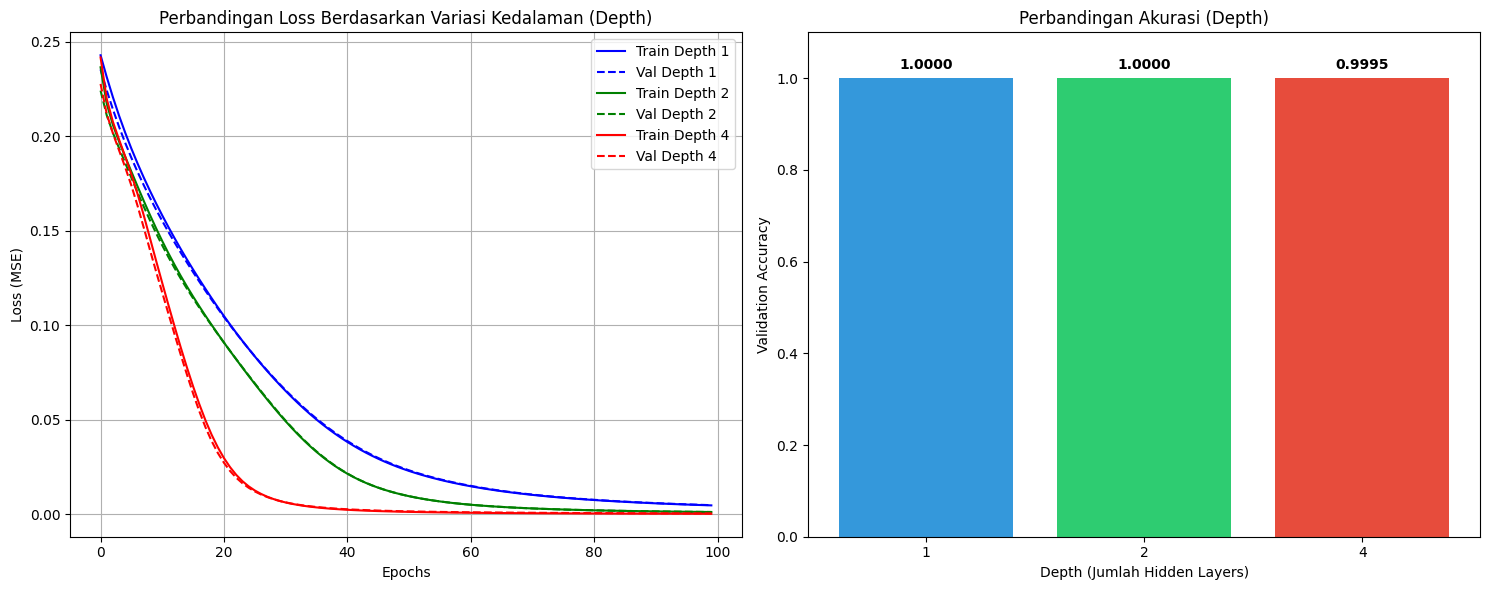

In [169]:
import matplotlib.pyplot as plt

depths = [1, 2, 4]
depth_results = {}
val_accuracies = []

for d in depths:
    print(f"\nTraining model dengan Depth: {d} Hidden Layers")
    
    model = NeuralNetwork()
    

    model.add(DenseLayer(24, 16, he_init))
    model.add(ActivationLayer(relu, relu_prime))
    
    for _ in range(d - 1):
        model.add(DenseLayer(16, 16, he_init))
        model.add(ActivationLayer(relu, relu_prime))
    
    # Output Layer
    model.add(DenseLayer(16, 1, xavier_init))
    model.add(ActivationLayer(sigmoid, sigmoid_prime))

    model.use(mse, mse_prime)

    depth_results[d] = model.train(
        X_train_np, y_train_np,
        X_val_np, y_val_np,
        epochs=100,
        batch_size=32,
        learning_rate=0.1,
        verbose=0
    )

    y_pred = model.predict(X_val_np)
    y_pred_binary = (np.array(y_pred).flatten() >= 0.5).astype(int)
    acc = accuracy_score(y_val_np, y_pred_binary)
    val_accuracies.append(acc)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
colors = ['blue', 'green', 'red']

for i, d in enumerate(depths):
    ax1.plot(depth_results[d]['train_loss'], color=colors[i], label=f'Train Depth {d}')
    ax1.plot(depth_results[d]['val_loss'], '--', color=colors[i], label=f'Val Depth {d}')

ax1.set_title('Perbandingan Loss Berdasarkan Variasi Kedalaman (Depth)')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss (MSE)')
ax1.legend()
ax1.grid(True)

ax2.set_title('Perbandingan Akurasi (Depth)')
ax2.set_xlabel('Depth (Jumlah Hidden Layers)')
ax2.set_ylabel('Validation Accuracy')
ax2.set_ylim(0, 1.1)
bars = ax2.bar([str(d) for d in depths], val_accuracies, color=['#3498db', '#2ecc71', '#e74c3c'])
for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.4f}', ha='center', fontweight='bold')

plt.tight_layout()

plt.show()

### Pengujian 1.2. Activation Function

Testing activation function: linear
Epoch 1/10, Train Loss=1.455036, Val Loss=1.414322
Epoch 2/10, Train Loss=1.371982, Val Loss=1.338948
Epoch 3/10, Train Loss=1.304278, Val Loss=1.277195
Epoch 4/10, Train Loss=1.248282, Val Loss=1.225619
Epoch 5/10, Train Loss=1.201216, Val Loss=1.182166
Epoch 6/10, Train Loss=1.161225, Val Loss=1.145023
Epoch 7/10, Train Loss=1.126834, Val Loss=1.112955
Epoch 8/10, Train Loss=1.096834, Val Loss=1.084896
Epoch 9/10, Train Loss=1.070400, Val Loss=1.060020
Epoch 10/10, Train Loss=1.046836, Val Loss=1.037707


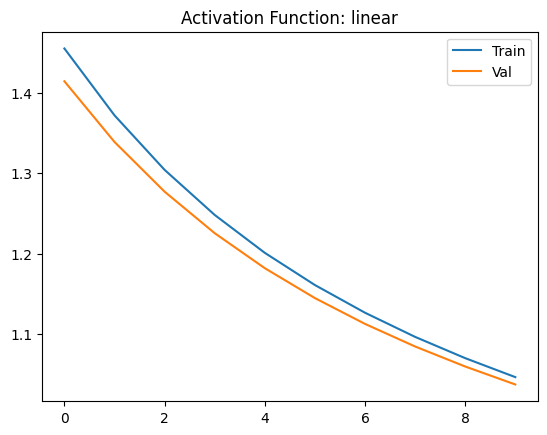

Testing activation function: relu
Epoch 1/10, Train Loss=1.334926, Val Loss=1.313723
Epoch 2/10, Train Loss=1.298367, Val Loss=1.279633
Epoch 3/10, Train Loss=1.266420, Val Loss=1.249592
Epoch 4/10, Train Loss=1.238196, Val Loss=1.222880
Epoch 5/10, Train Loss=1.213005, Val Loss=1.198901
Epoch 6/10, Train Loss=1.190255, Val Loss=1.177208
Epoch 7/10, Train Loss=1.169572, Val Loss=1.157473
Epoch 8/10, Train Loss=1.150645, Val Loss=1.139352
Epoch 9/10, Train Loss=1.133236, Val Loss=1.122673
Epoch 10/10, Train Loss=1.117124, Val Loss=1.107125


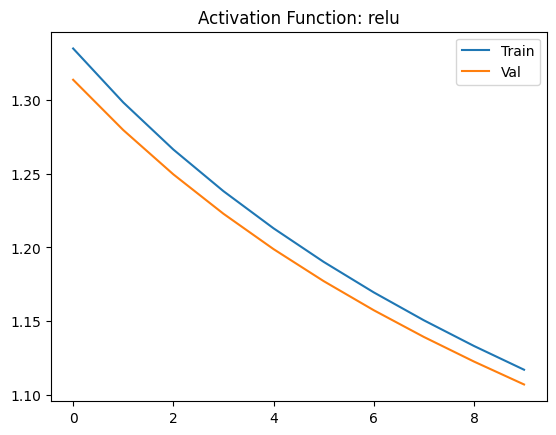

Testing activation function: sigmoid
Epoch 1/10, Train Loss=1.209820, Val Loss=1.204199
Epoch 2/10, Train Loss=1.201635, Val Loss=1.196596
Epoch 3/10, Train Loss=1.194405, Val Loss=1.189827
Epoch 4/10, Train Loss=1.187949, Val Loss=1.183759
Epoch 5/10, Train Loss=1.182131, Val Loss=1.178259
Epoch 6/10, Train Loss=1.176829, Val Loss=1.173217
Epoch 7/10, Train Loss=1.171950, Val Loss=1.168551
Epoch 8/10, Train Loss=1.167417, Val Loss=1.164191
Epoch 9/10, Train Loss=1.163162, Val Loss=1.160081
Epoch 10/10, Train Loss=1.159141, Val Loss=1.156182


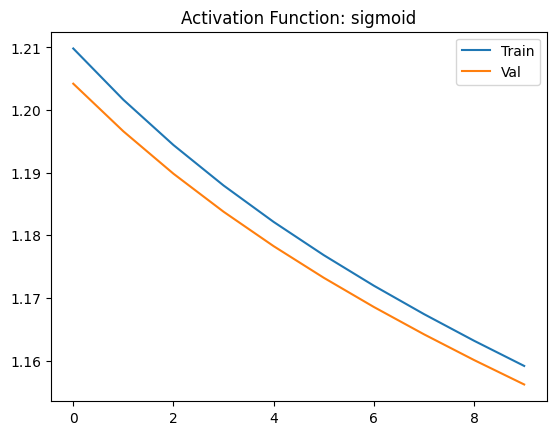

Testing activation function: tanh
Epoch 1/10, Train Loss=1.355974, Val Loss=1.337024
Epoch 2/10, Train Loss=1.321283, Val Loss=1.304029
Epoch 3/10, Train Loss=1.289882, Val Loss=1.274109
Epoch 4/10, Train Loss=1.261315, Val Loss=1.246801
Epoch 5/10, Train Loss=1.235207, Val Loss=1.221793
Epoch 6/10, Train Loss=1.211247, Val Loss=1.198820
Epoch 7/10, Train Loss=1.189146, Val Loss=1.177573
Epoch 8/10, Train Loss=1.168661, Val Loss=1.157841
Epoch 9/10, Train Loss=1.149576, Val Loss=1.139500
Epoch 10/10, Train Loss=1.131716, Val Loss=1.122353


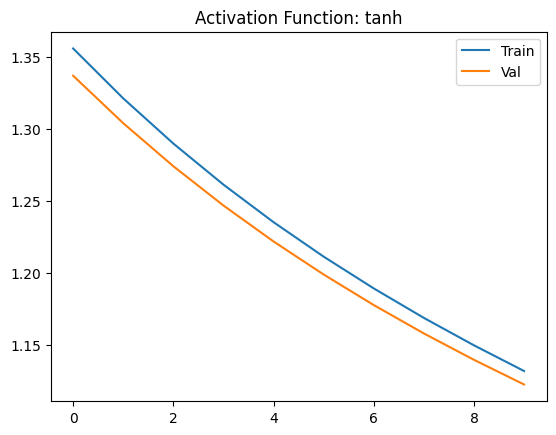

In [170]:
activation = {
    "linear": (linear, linear_prime),
    "relu": (relu, relu_prime),
    "sigmoid": (sigmoid, sigmoid_prime),
    "tanh": (hyperbolic_tangent, hyperbolic_tangent_prime),
}



for act in activation:
    print(f"Testing activation function: {act}")
    model = NeuralNetwork()
    model.add(DenseLayer(24, 16, he_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
    model.add(ActivationLayer(relu, relu_prime))
    model.add(DenseLayer(16, 16, he_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
    model.add(ActivationLayer(*activation[act]))
    model.add(DenseLayer(16, 1, xavier_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
    model.add(ActivationLayer(sigmoid, sigmoid_prime))

    model.use(bce, bce_prime)

    history = model.train(
        X_train_np, y_train_np,
        X_val_np, y_val_np,
        epochs=10,
        batch_size=32,
        learning_rate=0.01,
        verbose=1
    )

    plt.title(f"Activation Function: {act}")
    plt.plot(history['train_loss'], label='Train')
    plt.plot(history['val_loss'], label='Val')
    plt.legend()
    plt.show()


### Pengujian 1.3. Learning Rate

Testing learning rate: learning rate 0.0001
Epoch 1/10, Train Loss=0.785471, Val Loss=0.782693
Epoch 2/10, Train Loss=0.785408, Val Loss=0.782631
Epoch 3/10, Train Loss=0.785344, Val Loss=0.782568
Epoch 4/10, Train Loss=0.785280, Val Loss=0.782506
Epoch 5/10, Train Loss=0.785217, Val Loss=0.782443
Epoch 6/10, Train Loss=0.785153, Val Loss=0.782380
Epoch 7/10, Train Loss=0.785090, Val Loss=0.782318
Epoch 8/10, Train Loss=0.785026, Val Loss=0.782256
Epoch 9/10, Train Loss=0.784963, Val Loss=0.782193
Epoch 10/10, Train Loss=0.784899, Val Loss=0.782131


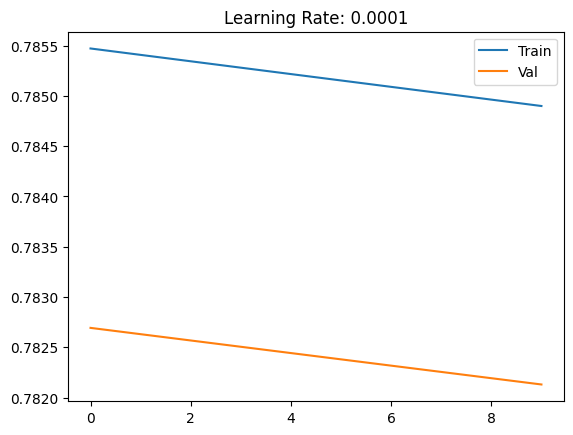

Testing learning rate: learning rate 0.001
Epoch 1/10, Train Loss=0.785187, Val Loss=0.782131
Epoch 2/10, Train Loss=0.784553, Val Loss=0.781508
Epoch 3/10, Train Loss=0.783922, Val Loss=0.780889
Epoch 4/10, Train Loss=0.783294, Val Loss=0.780273
Epoch 5/10, Train Loss=0.782669, Val Loss=0.779660
Epoch 6/10, Train Loss=0.782047, Val Loss=0.779049
Epoch 7/10, Train Loss=0.781429, Val Loss=0.778442
Epoch 8/10, Train Loss=0.780813, Val Loss=0.777838
Epoch 9/10, Train Loss=0.780200, Val Loss=0.777237
Epoch 10/10, Train Loss=0.779590, Val Loss=0.776639


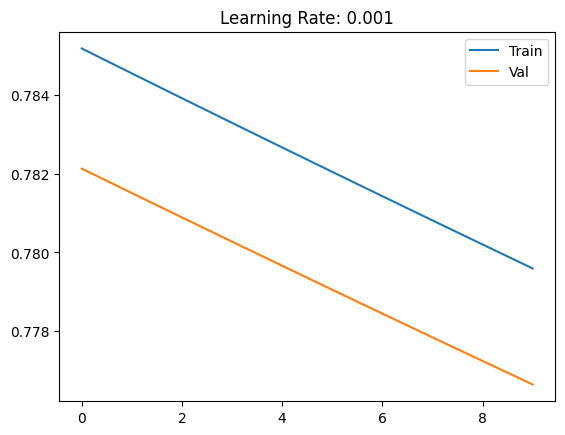

Testing learning rate: learning rate 0.01
Epoch 1/10, Train Loss=0.782385, Val Loss=0.776638
Epoch 2/10, Train Loss=0.776308, Val Loss=0.770802
Epoch 3/10, Train Loss=0.770490, Val Loss=0.765221
Epoch 4/10, Train Loss=0.764920, Val Loss=0.759870
Epoch 5/10, Train Loss=0.759585, Val Loss=0.754745
Epoch 6/10, Train Loss=0.754463, Val Loss=0.749814
Epoch 7/10, Train Loss=0.749527, Val Loss=0.745057
Epoch 8/10, Train Loss=0.744763, Val Loss=0.740460
Epoch 9/10, Train Loss=0.740158, Val Loss=0.736001
Epoch 10/10, Train Loss=0.735694, Val Loss=0.731670


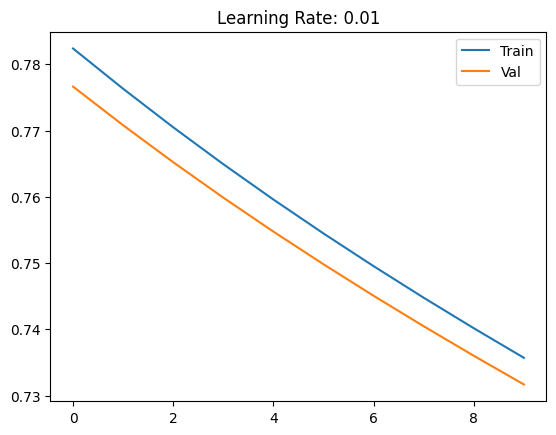

Testing learning rate: learning rate 0.1
Epoch 1/10, Train Loss=0.757945, Val Loss=0.731640
Epoch 2/10, Train Loss=0.713568, Val Loss=0.693548
Epoch 3/10, Train Loss=0.678243, Val Loss=0.661450
Epoch 4/10, Train Loss=0.648106, Val Loss=0.633760
Epoch 5/10, Train Loss=0.621886, Val Loss=0.609513
Epoch 6/10, Train Loss=0.598704, Val Loss=0.588038
Epoch 7/10, Train Loss=0.578026, Val Loss=0.568797
Epoch 8/10, Train Loss=0.559238, Val Loss=0.551056
Epoch 9/10, Train Loss=0.541897, Val Loss=0.534505
Epoch 10/10, Train Loss=0.525695, Val Loss=0.518969


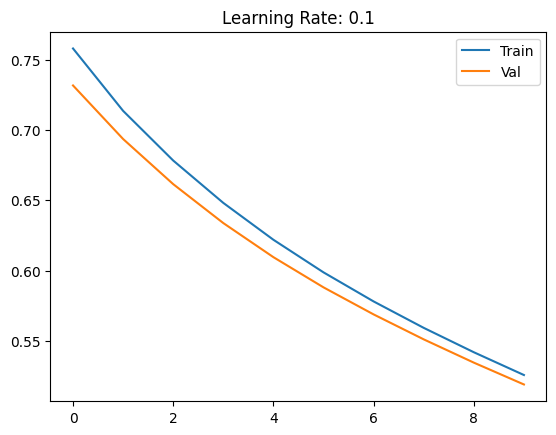

In [171]:
learning_rate = {
    "learning rate 0.0001": 0.0001,
    "learning rate 0.001": 0.001,
    "learning rate 0.01": 0.01,
    "learning rate 0.1": 0.1
}

for lr in learning_rate:
    print(f"Testing learning rate: {lr}")
    model = NeuralNetwork()
    model.add(DenseLayer(24, 16, he_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
    model.add(ActivationLayer(relu, relu_prime))
    model.add(DenseLayer(16, 16, he_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
    model.add(ActivationLayer(relu, relu_prime))
    model.add(DenseLayer(16, 1, xavier_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
    model.add(ActivationLayer(sigmoid, sigmoid_prime))

    model.use(mse, mse_prime)

    history = model.train(
        X_train_np, y_train_np,
        X_val_np, y_val_np,
        epochs=10,
        batch_size=32,
        learning_rate=learning_rate[lr],
        verbose=1
    )

    plt.title(f"Learning Rate: {learning_rate[lr]}")
    plt.plot(history['train_loss'], label='Train')
    plt.plot(history['val_loss'], label='Val')
    plt.legend()
    plt.show()


### Test Regularization

In [172]:
# init
bce = loss_fn.binary_cross_entropy
bce_prime = loss_fn.bce_prime

# helper build model
def build_regularization_model(l1_lambda=0.0, l2_lambda=0.0, seed=42):
    model = NeuralNetwork()

    model.add(DenseLayer(24, 16, he_init, l1_lambda=l1_lambda, l2_lambda=l2_lambda, seed=seed))
    model.add(ActivationLayer(relu, relu_prime))

    model.add(DenseLayer(16, 8, xavier_init, l1_lambda=l1_lambda, l2_lambda=l2_lambda, seed=seed))
    model.add(ActivationLayer(relu, relu_prime))

    model.add(DenseLayer(8, 1, xavier_init, l1_lambda=l1_lambda, l2_lambda=l2_lambda, seed=seed))
    model.add(ActivationLayer(sigmoid, sigmoid_prime))

    model.use(bce, bce_prime)
    return model

# helper evaluasi prediksi
def evaluate_binary_model(model, X_val, y_val, model_name="Model", threshold=0.5):
    y_prob = model.predict(X_val)
    y_pred = (y_prob >= threshold).astype(int).reshape(-1)
    y_true = y_val.reshape(-1)

    print()
    print(model_name)

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=["Not Placed", "Placed"],
        output_dict=True
    )

    report_df = pd.DataFrame(report_dict).transpose()
    accuracy = report_df.loc["accuracy", "precision"]
    report_df = report_df.drop("accuracy")
    display(report_df)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    print(f"Accuracy  : {acc:.4f}")
    print(f"Macro F1  : {macro_f1:.4f}")
    print()

    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "y_pred": y_pred,
        "y_prob": y_prob
    }

In [173]:
# init hyperparameter untuk regularization
EPOCHS = 20
BATCH_SIZE = 32
LEARNING_RATE = 0.01
REG_LAMBDA = 0.001
SEED = 42

#### a. Tanpa regularisasi

In [174]:
model_none = build_regularization_model(l1_lambda=0.0, l2_lambda=0.0, seed=SEED)

history_none = model_none.train(
    X_train_np, y_train_np,
    X_val_np, y_val_np,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    verbose=1
)

result_none = evaluate_binary_model(model_none, X_val_np, y_val_np, "No Regularization")

Epoch 1/20, Train Loss=0.693974, Val Loss=0.684209
Epoch 2/20, Train Loss=0.680743, Val Loss=0.671513
Epoch 3/20, Train Loss=0.668750, Val Loss=0.660016
Epoch 4/20, Train Loss=0.657805, Val Loss=0.649491
Epoch 5/20, Train Loss=0.647673, Val Loss=0.639650
Epoch 6/20, Train Loss=0.638184, Val Loss=0.630447
Epoch 7/20, Train Loss=0.629258, Val Loss=0.621724
Epoch 8/20, Train Loss=0.620724, Val Loss=0.613409
Epoch 9/20, Train Loss=0.612591, Val Loss=0.605436
Epoch 10/20, Train Loss=0.604758, Val Loss=0.597772
Epoch 11/20, Train Loss=0.597189, Val Loss=0.590390
Epoch 12/20, Train Loss=0.589848, Val Loss=0.583238
Epoch 13/20, Train Loss=0.582711, Val Loss=0.576281
Epoch 14/20, Train Loss=0.575742, Val Loss=0.569474
Epoch 15/20, Train Loss=0.568909, Val Loss=0.562798
Epoch 16/20, Train Loss=0.562186, Val Loss=0.556248
Epoch 17/20, Train Loss=0.555566, Val Loss=0.549812
Epoch 18/20, Train Loss=0.549061, Val Loss=0.543485
Epoch 19/20, Train Loss=0.542648, Val Loss=0.537224
Epoch 20/20, Train Lo

,precision,recall,f1-score,support
Not Placed,0.860248,0.360208,0.507791,769.0
Placed,0.706794,0.963444,0.815400,1231.0
macro avg,0.783521,0.661826,0.661596,2000.0
weighted avg,0.765797,0.731500,0.697125,2000.0


Accuracy  : 0.7315
Macro F1  : 0.6616



#### b. L1 Regularization

In [175]:
model_l1 = build_regularization_model(l1_lambda=REG_LAMBDA, l2_lambda=0.0, seed=SEED)

history_l1 = model_l1.train(
    X_train_np, y_train_np,
    X_val_np, y_val_np,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    verbose=1
)

result_l1 = evaluate_binary_model(model_l1, X_val_np, y_val_np, "L1 Regularization")

Epoch 1/20, Train Loss=0.815010, Val Loss=0.805238
Epoch 2/20, Train Loss=0.801768, Val Loss=0.792541
Epoch 3/20, Train Loss=0.789783, Val Loss=0.781055
Epoch 4/20, Train Loss=0.778857, Val Loss=0.770549
Epoch 5/20, Train Loss=0.768747, Val Loss=0.760736
Epoch 6/20, Train Loss=0.759289, Val Loss=0.751558
Epoch 7/20, Train Loss=0.750394, Val Loss=0.742872
Epoch 8/20, Train Loss=0.741903, Val Loss=0.734600
Epoch 9/20, Train Loss=0.733815, Val Loss=0.726673
Epoch 10/20, Train Loss=0.726030, Val Loss=0.719059
Epoch 11/20, Train Loss=0.718518, Val Loss=0.711732
Epoch 12/20, Train Loss=0.711233, Val Loss=0.704638
Epoch 13/20, Train Loss=0.704157, Val Loss=0.697742
Epoch 14/20, Train Loss=0.697251, Val Loss=0.690999
Epoch 15/20, Train Loss=0.690488, Val Loss=0.684386
Epoch 16/20, Train Loss=0.683828, Val Loss=0.677897
Epoch 17/20, Train Loss=0.677288, Val Loss=0.671540
Epoch 18/20, Train Loss=0.670864, Val Loss=0.665290
Epoch 19/20, Train Loss=0.664531, Val Loss=0.659115
Epoch 20/20, Train Lo

,precision,recall,f1-score,support
Not Placed,0.859813,0.358908,0.506422,769.0
Placed,0.706373,0.963444,0.815120,1231.0
macro avg,0.783093,0.661176,0.660771,2000.0
weighted avg,0.765371,0.731000,0.696426,2000.0


Accuracy  : 0.7310
Macro F1  : 0.6608



#### c. L2 Regularization

In [176]:
model_l2 = build_regularization_model(l1_lambda=0.0, l2_lambda=REG_LAMBDA, seed=SEED)

history_l2 = model_l2.train(
    X_train_np, y_train_np,
    X_val_np, y_val_np,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    verbose=1
)

result_l2 = evaluate_binary_model(model_l2, X_val_np, y_val_np, "L2 Regularization")

Epoch 1/20, Train Loss=0.715305, Val Loss=0.705533


Epoch 2/20, Train Loss=0.702061, Val Loss=0.692829
Epoch 3/20, Train Loss=0.690063, Val Loss=0.681330
Epoch 4/20, Train Loss=0.679119, Val Loss=0.670810
Epoch 5/20, Train Loss=0.668992, Val Loss=0.660978
Epoch 6/20, Train Loss=0.659514, Val Loss=0.651788
Epoch 7/20, Train Loss=0.650602, Val Loss=0.643081
Epoch 8/20, Train Loss=0.642086, Val Loss=0.634787
Epoch 9/20, Train Loss=0.633974, Val Loss=0.626838
Epoch 10/20, Train Loss=0.626166, Val Loss=0.619199
Epoch 11/20, Train Loss=0.618624, Val Loss=0.611845
Epoch 12/20, Train Loss=0.611312, Val Loss=0.604724
Epoch 13/20, Train Loss=0.604206, Val Loss=0.597800
Epoch 14/20, Train Loss=0.597273, Val Loss=0.591029
Epoch 15/20, Train Loss=0.590476, Val Loss=0.584390
Epoch 16/20, Train Loss=0.583790, Val Loss=0.577877
Epoch 17/20, Train Loss=0.577210, Val Loss=0.571481
Epoch 18/20, Train Loss=0.570747, Val Loss=0.565194
Epoch 19/20, Train Loss=0.564376, Val Loss=0.558977
Epoch 20/20, Train Loss=0.558101, Val Loss=0.552831

L2 Regularization


,precision,recall,f1-score,support
Not Placed,0.859813,0.358908,0.506422,769.0
Placed,0.706373,0.963444,0.815120,1231.0
macro avg,0.783093,0.661176,0.660771,2000.0
weighted avg,0.765371,0.731000,0.696426,2000.0


Accuracy  : 0.7310
Macro F1  : 0.6608



#### Perbandingan Regularisasi

In [177]:
# tabel perbandingan
comparison_df = pd.DataFrame([
    {
        "Model": "No Regularization",
        "Accuracy": result_none["accuracy"],
        "Macro F1": result_none["macro_f1"]
    },
    {
        "Model": "L1 Regularization",
        "Accuracy": result_l1["accuracy"],
        "Macro F1": result_l1["macro_f1"]
    },
    {
        "Model": "L2 Regularization",
        "Accuracy": result_l2["accuracy"],
        "Macro F1": result_l2["macro_f1"]
    }
])

comparison_df.sort_values(by="Macro F1", ascending=False)

,Model,Accuracy,Macro F1
0,No Regularization,0.7315,0.661596
1,L1 Regularization,0.7310,0.660771
2,L2 Regularization,0.7310,0.660771


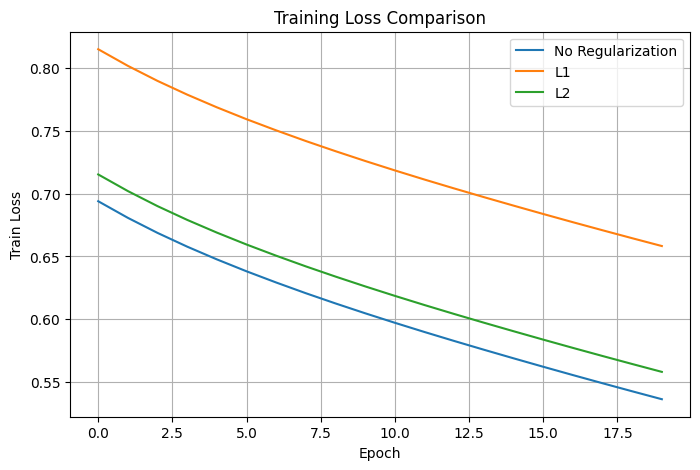

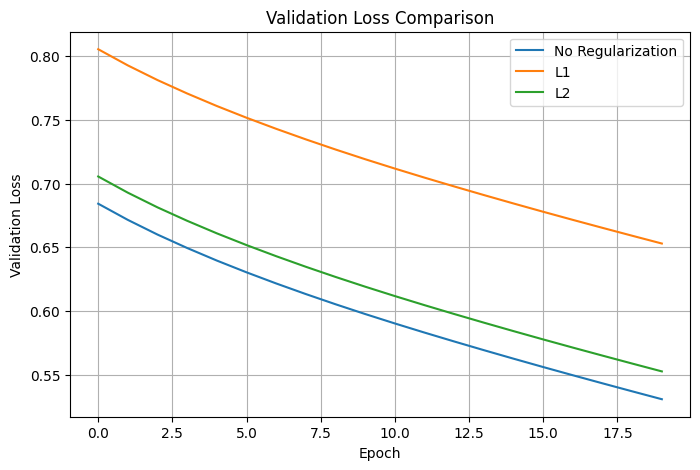


Weight Distribution - No Regularization


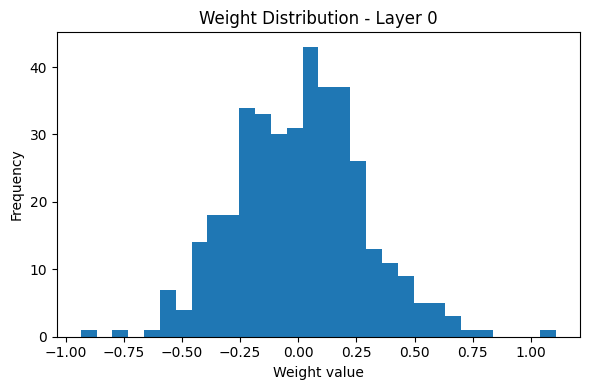

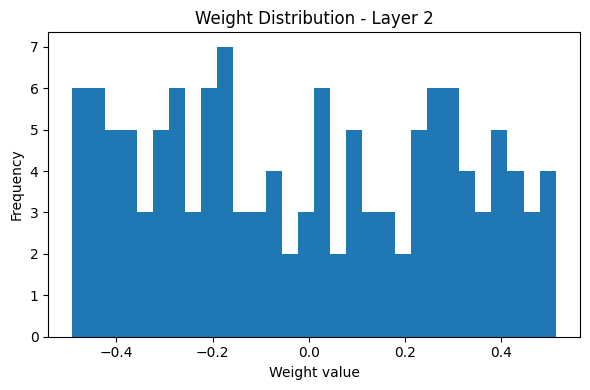

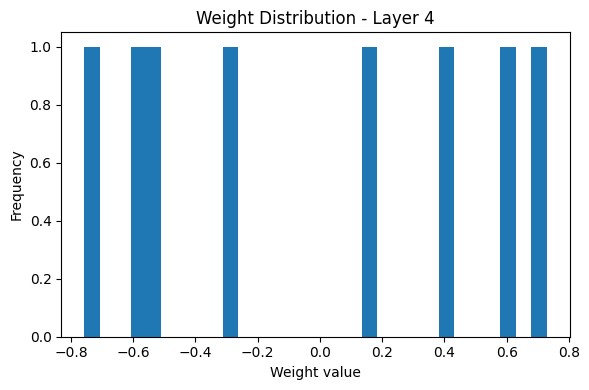

Weight Distribution - L1 Regularization


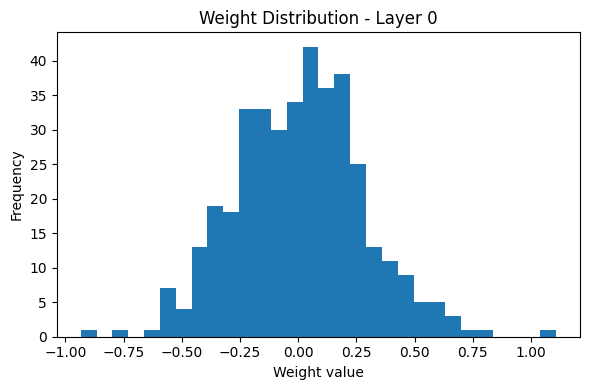

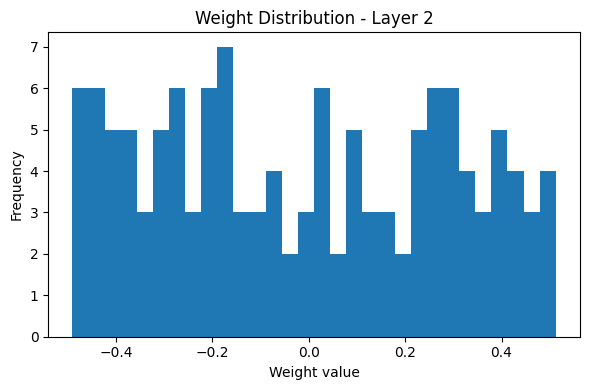

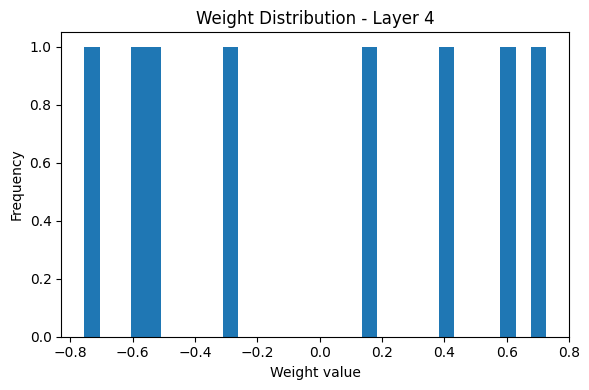

Weight Distribution - L2 Regularization


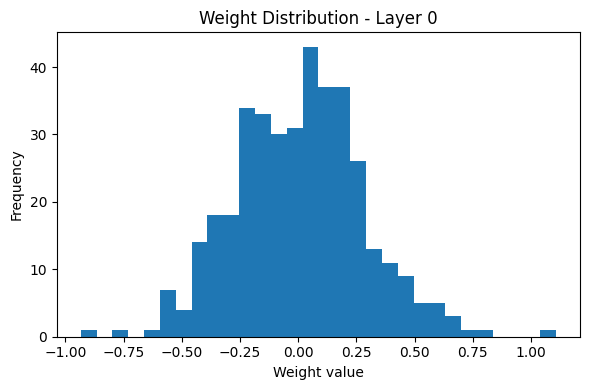

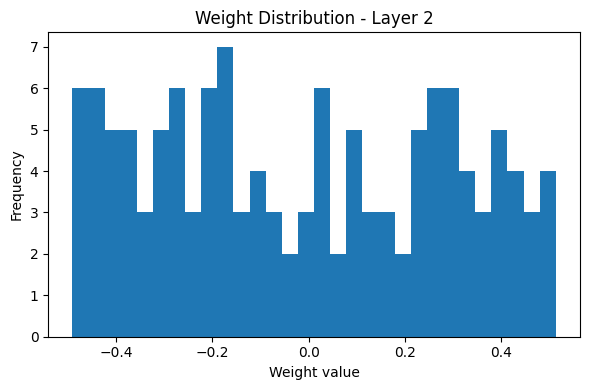

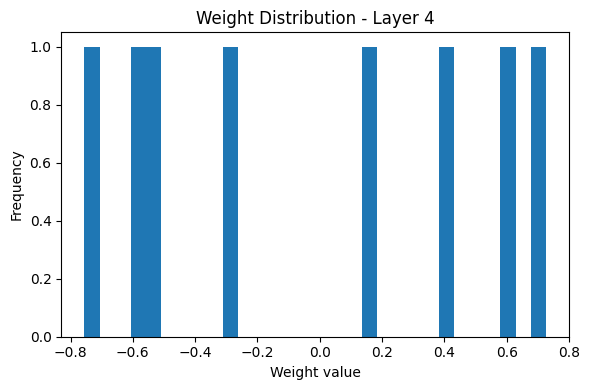


Gradient Distribution - No Regularization


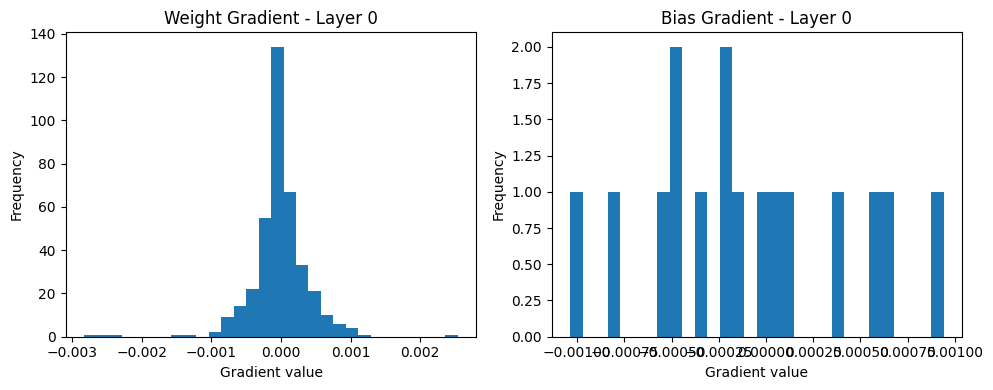

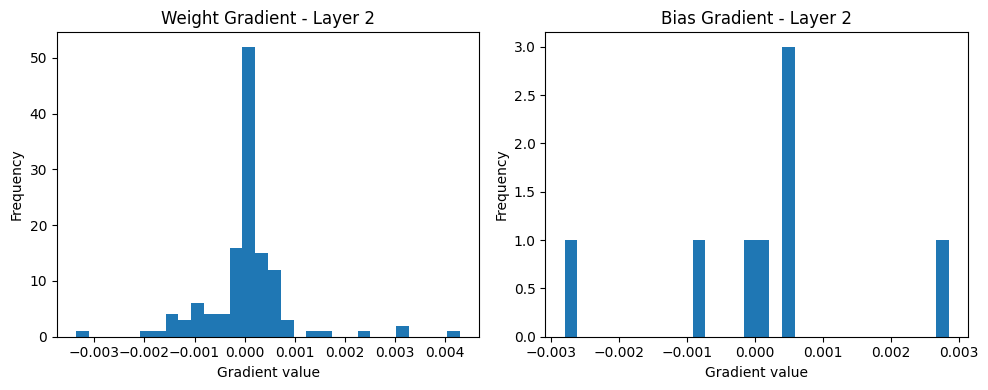

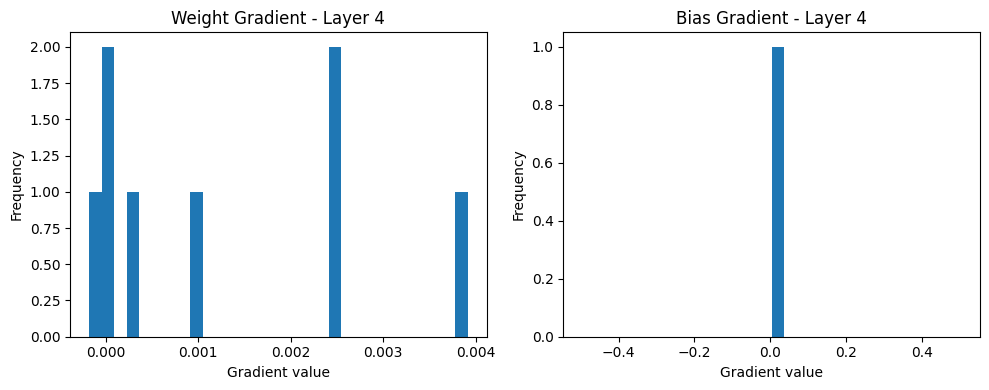

Gradient Distribution - L1 Regularization


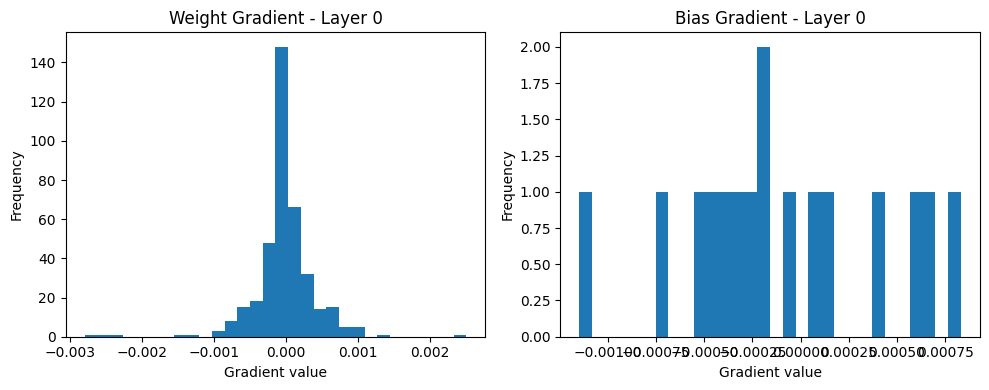

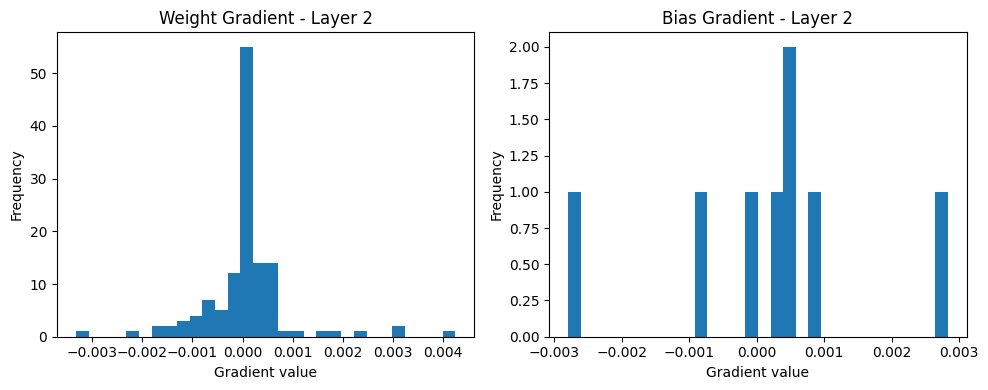

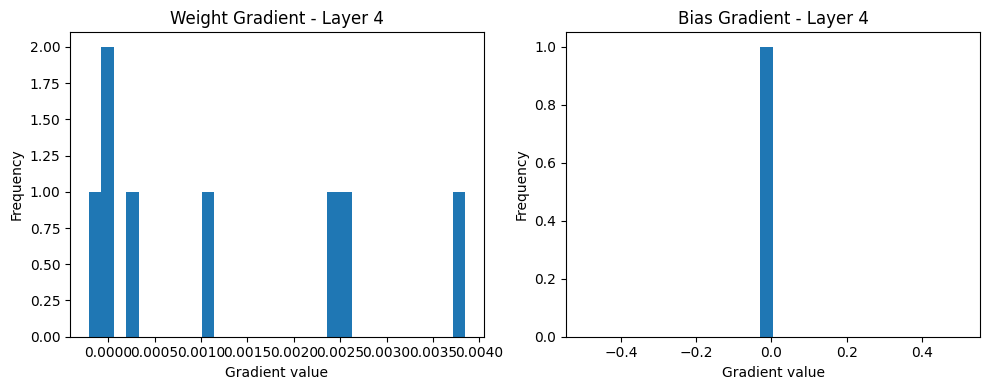

Gradient Distribution - L2 Regularization


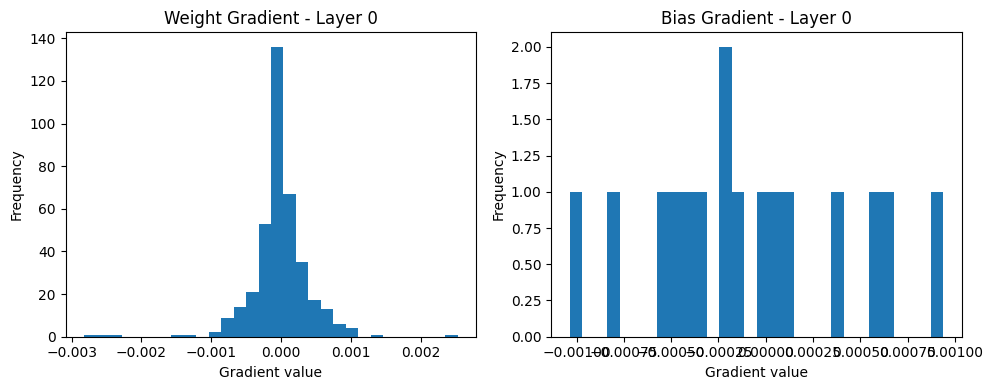

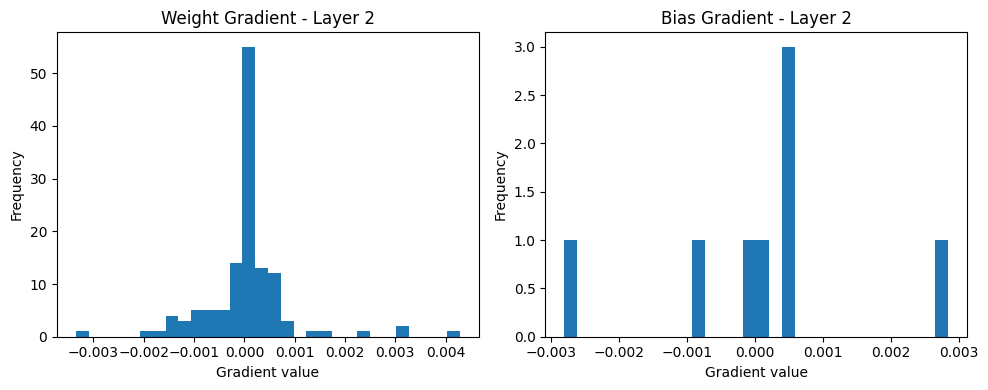

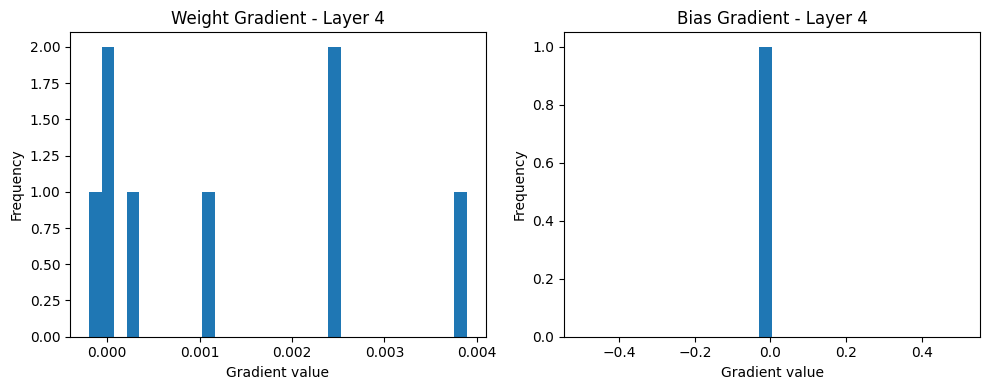

In [178]:
# plot training loss
plt.figure(figsize=(8, 5))
plt.plot(history_none["train_loss"], label="No Regularization")
plt.plot(history_l1["train_loss"], label="L1")
plt.plot(history_l2["train_loss"], label="L2")
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()

# plot validation loss
plt.figure(figsize=(8, 5))
plt.plot(history_none["val_loss"], label="No Regularization")
plt.plot(history_l1["val_loss"], label="L1")
plt.plot(history_l2["val_loss"], label="L2")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()

# plot distribusi weight
print("\nWeight Distribution - No Regularization")
model_none.plot_weight_distribution([0, 2, 4])

print("Weight Distribution - L1 Regularization")
model_l1.plot_weight_distribution([0, 2, 4])

print("Weight Distribution - L2 Regularization")
model_l2.plot_weight_distribution([0, 2, 4])

# plot distribusi gradient
print("\nGradient Distribution - No Regularization")
model_none.plot_gradient_distribution([0, 2, 4])

print("Gradient Distribution - L1 Regularization")
model_l1.plot_gradient_distribution([0, 2, 4])

print("Gradient Distribution - L2 Regularization")
model_l2.plot_gradient_distribution([0, 2, 4])

#### Uji Perbandingan dengan Sklearn

In [179]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score

In [180]:
# init hyperparameter
SEED = 42
EPOCHS = 50
LEARNING_RATE = 0.01
BATCH_SIZE = 32

In [181]:
custom_model = build_regularization_model(l1_lambda=0.0, l2_lambda=0.0, seed=SEED)

history_custom = custom_model.train(
    X_train_np, y_train_np,
    X_val_np, y_val_np,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    verbose=1
)

custom_result = evaluate_binary_model(
    custom_model,
    X_val_np,
    y_val_np,
    model_name="Custom FFNN"
)

# train model sklearn
sklearn_model = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation="relu",
    solver="adam",
    learning_rate="constant",
    learning_rate_init=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    max_iter=EPOCHS,
    shuffle=True,
    random_state=SEED,
    alpha=0.0
)

sklearn_model.fit(X_train_np, y_train_np.reshape(-1))

def evaluate_sklearn_model(model, X_val, y_val, model_name="Sklearn MLP"):
    y_pred = model.predict(X_val)
    y_true = y_val.reshape(-1)

    print()
    print(model_name)

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=["Not Placed", "Placed"],
        output_dict=True
    )

    report_df = pd.DataFrame(report_dict).transpose()
    report_df = report_df.drop("accuracy")
    display(report_df)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    print(f"Accuracy  : {acc:.4f}")
    print(f"Macro F1  : {macro_f1:.4f}")
    print()

    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "y_pred": y_pred
    }

sklearn_result = evaluate_sklearn_model(
    sklearn_model,
    X_val_np,
    y_val_np,
    model_name="Sklearn MLPClassifier"
)

Epoch 1/50, Train Loss=0.693974, Val Loss=0.684209
Epoch 2/50, Train Loss=0.680743, Val Loss=0.671513
Epoch 3/50, Train Loss=0.668750, Val Loss=0.660016
Epoch 4/50, Train Loss=0.657805, Val Loss=0.649491
Epoch 5/50, Train Loss=0.647673, Val Loss=0.639650
Epoch 6/50, Train Loss=0.638184, Val Loss=0.630447
Epoch 7/50, Train Loss=0.629258, Val Loss=0.621724
Epoch 8/50, Train Loss=0.620724, Val Loss=0.613409
Epoch 9/50, Train Loss=0.612591, Val Loss=0.605436
Epoch 10/50, Train Loss=0.604758, Val Loss=0.597772
Epoch 11/50, Train Loss=0.597189, Val Loss=0.590390
Epoch 12/50, Train Loss=0.589848, Val Loss=0.583238
Epoch 13/50, Train Loss=0.582711, Val Loss=0.576281
Epoch 14/50, Train Loss=0.575742, Val Loss=0.569474
Epoch 15/50, Train Loss=0.568909, Val Loss=0.562798
Epoch 16/50, Train Loss=0.562186, Val Loss=0.556248
Epoch 17/50, Train Loss=0.555566, Val Loss=0.549812
Epoch 18/50, Train Loss=0.549061, Val Loss=0.543485
Epoch 19/50, Train Loss=0.542648, Val Loss=0.537224
Epoch 20/50, Train Lo

,precision,recall,f1-score,support
Not Placed,0.906463,0.693108,0.785556,769.0
Placed,0.832861,0.955321,0.889898,1231.0
macro avg,0.869662,0.824214,0.837727,2000.0
weighted avg,0.861161,0.854500,0.849779,2000.0


Accuracy  : 0.8545
Macro F1  : 0.8377


Sklearn MLPClassifier


,precision,recall,f1-score,support
Not Placed,1.0,1.0,1.0,769.0
Placed,1.0,1.0,1.0,1231.0
macro avg,1.0,1.0,1.0,2000.0
weighted avg,1.0,1.0,1.0,2000.0


Accuracy  : 1.0000
Macro F1  : 1.0000



#### Tabel Perbandingan

In [182]:
comparison_sklearn_df = pd.DataFrame([
    {
        "Model": "Custom FFNN",
        "Accuracy": custom_result["accuracy"],
        "Macro F1": custom_result["macro_f1"]
    },
    {
        "Model": "Sklearn MLPClassifier",
        "Accuracy": sklearn_result["accuracy"],
        "Macro F1": sklearn_result["macro_f1"]
    }
])

display(comparison_sklearn_df)

,Model,Accuracy,Macro F1
0,Custom FFNN,0.8545,0.837727
1,Sklearn MLPClassifier,1.0000,1.000000
